# Homework — Customer Segmentation with Wholesale Customers

## Brief

Bạn là analyst cho một nhà phân phối thực phẩm. Hãy dùng dữ liệu **Wholesale Customers** để trả lời một câu hỏi thực tế:

> Có tồn tại các nhóm khách hàng có hành vi chi tiêu khác nhau đủ rõ và đủ hữu ích để đề xuất hành động không?

Dữ liệu có 440 khách hàng và 6 nhóm chi tiêu hằng năm: `Fresh`, `Milk`, `Grocery`, `Frozen`, `Detergents_Paper`, `Delicassen`.

Đây là **notebook làm việc của bạn**, không phải chuỗi bước cần làm lại. Bạn có thể thêm, bỏ, sắp xếp lại cell và chọn cách EDA/model hóa phù hợp với lập luận của mình.

## Yêu cầu đầu ra

Nộp một báo cáo notebook có thể giúp người khác ra quyết định. Bài làm cần có:

- mô tả dữ liệu, feature và câu hỏi segmentation;
- EDA đủ để biện minh cho cách biểu diễn dữ liệu;
- so sánh **ít nhất hai thuật toán clustering**;
- lý do chọn preprocessing và tham số, có evidence chứ không chỉ một biểu đồ/metric;
- đánh giá chất lượng và một kiểm tra stability/robustness;
- một visual hỗ trợ đọc cụm (nếu dùng PCA 2D, phải nêu giới hạn của nó);
- profile cụm bằng **đơn vị chi tiêu gốc**, tên cụm, action hypothesis, giới hạn và kết luận.

Không có yêu cầu về số lượng biểu đồ, thứ tự section hay thư viện. Chất lượng lập luận quan trọng hơn số cell/code.

## Quy ước và lưu ý

- Sáu cột chi tiêu là input mặc định cho clustering.
- `Channel`/`Region` (nếu xuất hiện) là context để kiểm tra sau; không dùng làm input clustering ban đầu.
- Giữ một bản dữ liệu gốc để profile/diễn giải. Data đã scale chỉ nên phục vụ model.
- Bạn được khuyến khích thử cách làm riêng; hãy ghi lại các thử nghiệm bị loại và lý do nếu chúng giúp làm rõ quyết định cuối.

Nộp `.ipynb` đã chạy đầy đủ. Tên file: `HW_clustering_<student_id>.ipynb`.

In [26]:
# Nếu môi trường thiếu thư viện, bỏ comment và chạy một lần:
# %pip install numpy pandas matplotlib scikit-learn scipy ucimlrepo

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import AgglomerativeClustering, DBSCAN, KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import adjusted_rand_score, davies_bouldin_score, silhouette_score, calinski_harabasz_score
from sklearn.preprocessing import MinMaxScaler, RobustScaler, StandardScaler

plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.float_format', lambda value: f'{value:,.2f}')
RANDOM_STATE = 42


# Dữ liệu

Cell này chỉ nạp dữ liệu và tách phần chi tiêu. Từ đây, bạn tự xây dựng analysis workspace của mình.

In [27]:
SPENDING_FEATURES = [
    'Fresh', 'Milk', 'Grocery', 'Frozen', 'Detergents_Paper', 'Delicassen'
]

candidate_paths = [
    Path('data/wholesale_customers.csv'),
    Path('../data/wholesale_customers.csv'),
    Path('../../data/wholesale_customers.csv'),
]
data_path = next((path for path in candidate_paths if path.exists()), None)

if data_path is not None:
    df = pd.read_csv(data_path)
    source = str(data_path)
else:
    try:
        from ucimlrepo import fetch_ucirepo
        dataset = fetch_ucirepo(id=292)
        df = dataset.data.features.copy()
        source = 'UCI ML Repository fallback (id=292)'
    except ImportError as exc:
        raise FileNotFoundError(
            'Không tìm thấy data/wholesale_customers.csv. '
            'Hãy đặt file đúng đường dẫn hoặc cài ucimlrepo để dùng fallback.'
        ) from exc

missing = sorted(set(SPENDING_FEATURES) - set(df.columns))
if missing:
    raise ValueError(f'File thiếu cột chi tiêu: {missing}')

X_raw = df[SPENDING_FEATURES].copy()
print(f'Nguồn: {source}')
print(f'Dữ liệu đầy đủ: {df.shape[0]} dòng × {df.shape[1]} cột')
print(f'Matrix chi tiêu: {X_raw.shape[0]} dòng × {X_raw.shape[1]} features')
display(df.head())


Nguồn: UCI ML Repository fallback (id=292)
Dữ liệu đầy đủ: 440 dòng × 7 cột
Matrix chi tiêu: 440 dòng × 6 features


,Channel,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
0,2,12669,9656,7561,214,2674,1338
1,2,7057,9810,9568,1762,3293,1776
2,2,6353,8808,7684,2405,3516,7844
3,1,13265,1196,4221,6404,507,1788
4,2,22615,5410,7198,3915,1777,5185


# TODO A — Framing và audit dữ liệu

Hãy thêm cell/cell Markdown của bạn để trả lời:

- Một dòng dữ liệu đại diện cho điều gì? Những feature nào có ý nghĩa cho bài toán segmentation?
- Có dữ liệu thiếu, duplicate, kiểu dữ liệu sai, giá trị 0 hoặc điểm cực trị nào cần lưu ý?
- `Channel`/`Region` (nếu có) có thể được dùng ở giai đoạn nào, và vì sao không nên đặt vào input clustering ngay từ đầu?
- Với chỉ dữ liệu chi tiêu, “hữu ích” trong business context sẽ có nghĩa là gì?

Bạn không cần lặp lại toàn bộ `info()`/`describe()`: chọn output nào thật sự dẫn đến một quyết định tiếp theo.

In [28]:
# Analysis workspace — thêm cell EDA của bạn bên dưới hoặc thay cell này.
# Gợi ý khởi đầu (không bắt buộc):
display(X_raw.describe().T)

,count,mean,std,min,25%,50%,75%,max
Fresh,440.00,"12,000.30","12,647.33",3.00,"3,127.75","8,504.00","16,933.75","112,151.00"
Milk,440.00,"5,796.27","7,380.38",55.00,"1,533.00","3,627.00","7,190.25","73,498.00"
Grocery,440.00,"7,951.28","9,503.16",3.00,"2,153.00","4,755.50","10,655.75","92,780.00"
Frozen,440.00,"3,071.93","4,854.67",25.00,742.25,"1,526.00","3,554.25","60,869.00"
Detergents_Paper,440.00,"2,881.49","4,767.85",3.00,256.75,816.50,"3,922.00","40,827.00"
Delicassen,440.00,"1,524.87","2,820.11",3.00,408.25,965.50,"1,820.25","47,943.00"


In [29]:
# In ra các cột
print(X_raw.columns)  

Index(['Fresh', 'Milk', 'Grocery', 'Frozen', 'Detergents_Paper', 'Delicassen'], dtype='str')


Một dòng dữ liệu bao gồm có: 
- `Fresh`: chi tiêu cho thực phẩm tươi sống
- `Milk`: chi tiêu cho sửa và các thực phẩm từ sữa
- `Grocery`: chi tiêu cho hàng tạp hóa
- `Frozen`: chi tiêu cho thực phẩm đông lạnh
- `Detergents_Paper`: chi tiêu cho chất tầy rửa và sản phẩm giấy
- `Delicassen`: chi tiêu cho thực phẩm chế biến sẵn
Tất cả đều có ý nghĩa cho bài toán segmentation

In [30]:
print("Kiểm tra missing values")
missing_table = pd.DataFrame({
    "missing": X_raw.isnull().sum(),
    "missing_percentage": X_raw.isnull().sum().mean() * 100,
})
print(missing_table)
print()
print("Kiểm tra duplicate")
print(X_raw.duplicated().sum())
print()
print("Kiểm tra kiểu dữ liệu")
print(X_raw.info())

print()
print("Kiểm tra các giá trị bằng 0")
print((X_raw == 0).sum())

print()
print("Kiểm tra các outlier")
cols = [
    "Fresh", "Milk", "Grocery",
    "Frozen", "Detergents_Paper", "Delicassen"
]

Q1 = df[cols].quantile(0.25)
Q3 = df[cols].quantile(0.75)
IQR = Q3 - Q1

outliers = ((df[cols] < (Q1 - 1.5 * IQR)) |
            (df[cols] > (Q3 + 1.5 * IQR)))

# Số outlier của từng cột
outlier_table = pd.DataFrame({
    "outliers": outliers.sum(),
    "percentage": (outliers.mean())
})
print(outlier_table)


Kiểm tra missing values
                  missing  missing_percentage
Fresh                   0                0.00
Milk                    0                0.00
Grocery                 0                0.00
Frozen                  0                0.00
Detergents_Paper        0                0.00
Delicassen              0                0.00

Kiểm tra duplicate
0

Kiểm tra kiểu dữ liệu
<class 'pandas.DataFrame'>
RangeIndex: 440 entries, 0 to 439
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Fresh             440 non-null    int64
 1   Milk              440 non-null    int64
 2   Grocery           440 non-null    int64
 3   Frozen            440 non-null    int64
 4   Detergents_Paper  440 non-null    int64
 5   Delicassen        440 non-null    int64
dtypes: int64(6)
memory usage: 20.8 KB
None

Kiểm tra các giá trị bằng 0
Fresh               0
Milk                0
Grocery             0
Frozen           

Không có dữ liệu thiếu, dự liệu lặp, kiểu dữ liệu sai <br>
Có xuất hiện các outlier (chiếm tỉ lệ rất ít)

Không có `Channel` và `Region` <br>
Không nên đặt vào input clustering ngay từ đầu vì đây là các biến mô tả, không phản ánh trực tiếp hành vi mua hàng <br>
Nên dùng khi phân tích và diễn giải đặc điểm của từng cụm sau khi phân cụm xong

Với chỉ dữ liệu chi tiêu, “hữu ích” trong business context sẽ có nghĩa là:
 - Mô tả được hành vi của khách hàng
 - Giúp doanh nghiệp đưa ra được quyết định

# TODO B — EDA tự do, nhưng có chủ đích

Tự chọn visual và phép tóm tắt phù hợp. EDA của bạn cần làm rõ các câu hỏi sau:

- Phân phối/độ lệch/outlier nào sẽ ảnh hưởng cách tính khoảng cách?
- Feature nào có thang đo hoặc mức biến thiên khác đáng kể?
- Có quan hệ giữa các nhóm chi tiêu nào đáng để chú ý khi đọc cluster profile?
- Những quan sát này dẫn bạn đến thử preprocessing hoặc model nào?

Gắn một đoạn nhận xét ngắn dưới mỗi visual quan trọng. Không cần vẽ mọi loại biểu đồ nếu chúng không giúp trả lời câu hỏi.

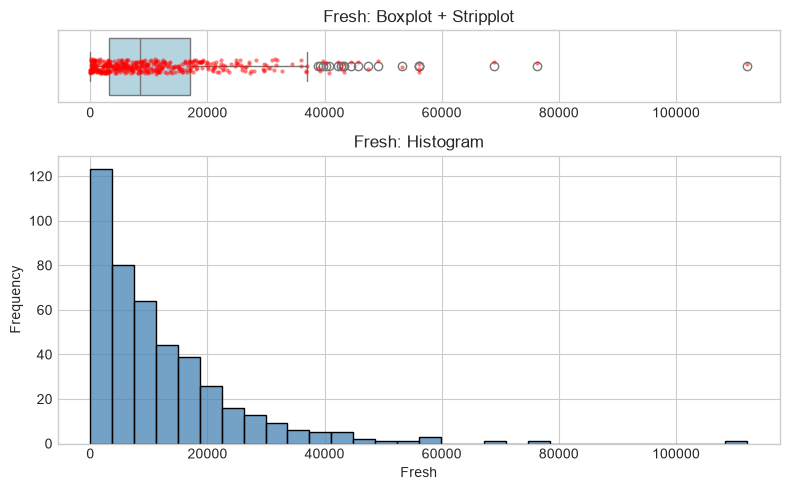

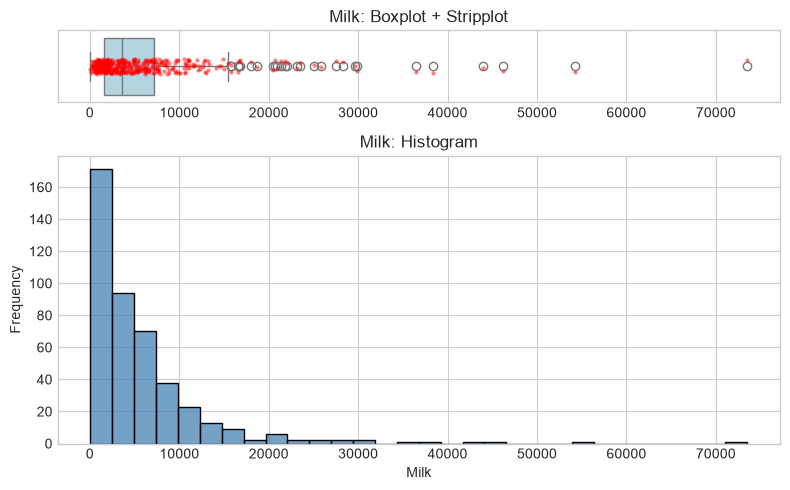

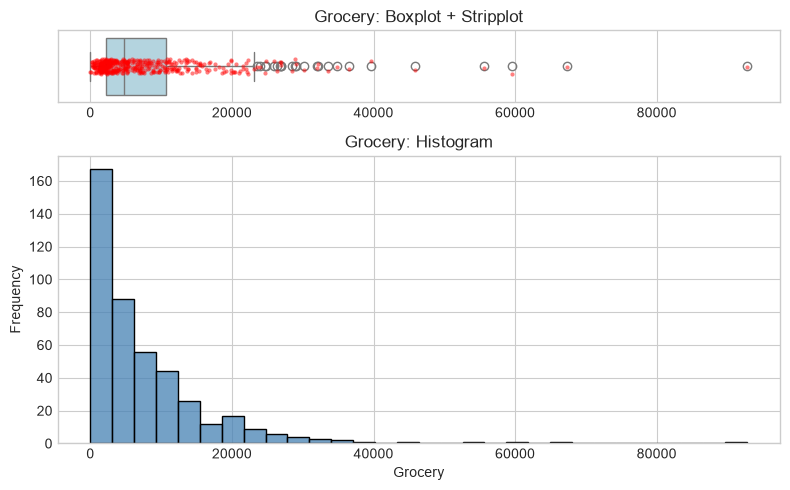

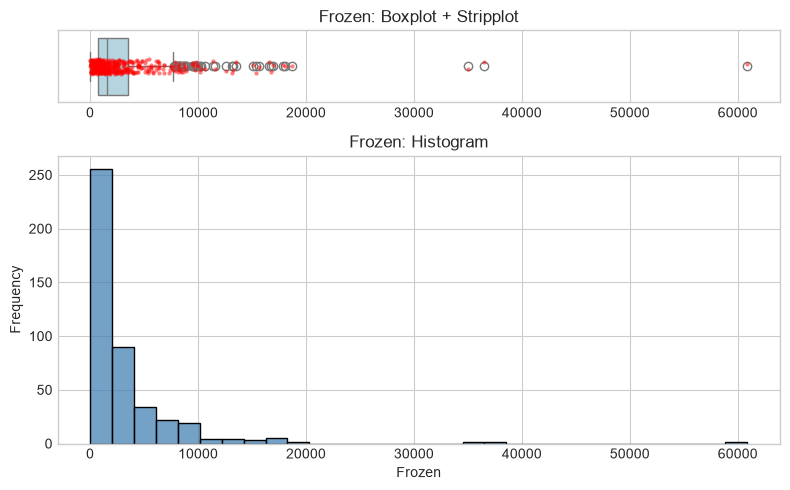

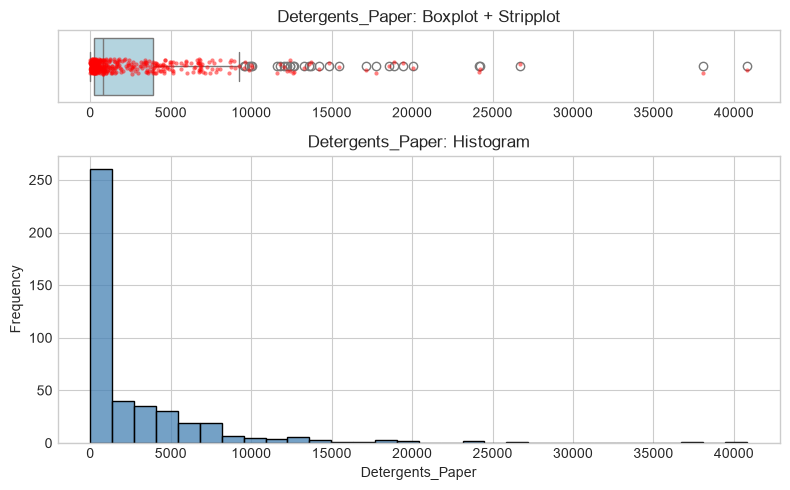

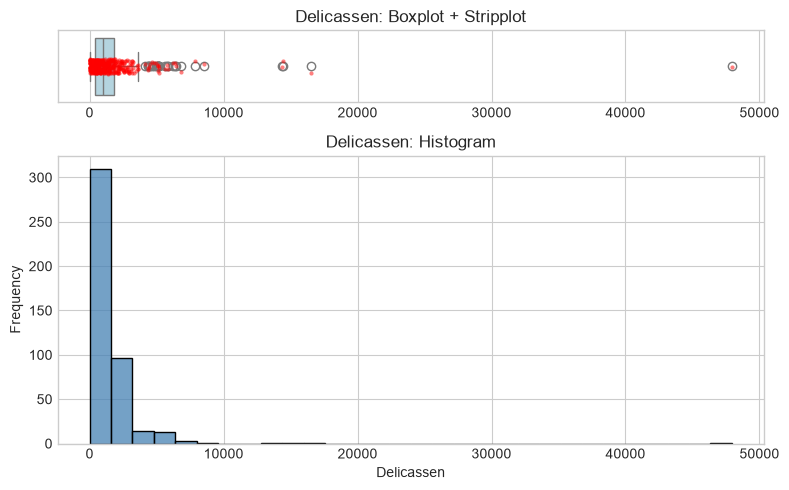

In [31]:
cols = [
    "Fresh", "Milk", "Grocery",
    "Frozen", "Detergents_Paper", "Delicassen"
]

for col in cols:
    fig, axes = plt.subplots(
        2, 1,
        figsize=(8, 5),
        gridspec_kw={"height_ratios": [1, 4]}
    )

    # Boxplot + Stripplot
    sns.boxplot(
        x=df[col],
        ax=axes[0],
        color="lightblue"
    )

    sns.stripplot(
        x=df[col],
        ax=axes[0],
        color="red",
        size=3,
        alpha=0.5
    )

    axes[0].set_title(f"{col}: Boxplot + Stripplot")
    axes[0].set_xlabel("")

    # Histogram
    sns.histplot(
        df[col],
        bins=30,
        ax=axes[1],
        color="steelblue"
    )

    axes[1].set_title(f"{col}: Histogram")
    axes[1].set_xlabel(col)
    axes[1].set_ylabel("Frequency")

    plt.tight_layout()
    plt.show()

 - Tất cả các đặc trưng đều lệch phải (cho thấy đa số mọi người đều có mức chi tiêu không nhiều) 
 - Outliers trải dài nhưng chiếm tỉ lệ ít
Đề xuất sử dụng `log_transformation` để chuẩn hóa dữ liệu

In [32]:
display(X_raw.describe().T)

,count,mean,std,min,25%,50%,75%,max
Fresh,440.00,"12,000.30","12,647.33",3.00,"3,127.75","8,504.00","16,933.75","112,151.00"
Milk,440.00,"5,796.27","7,380.38",55.00,"1,533.00","3,627.00","7,190.25","73,498.00"
Grocery,440.00,"7,951.28","9,503.16",3.00,"2,153.00","4,755.50","10,655.75","92,780.00"
Frozen,440.00,"3,071.93","4,854.67",25.00,742.25,"1,526.00","3,554.25","60,869.00"
Detergents_Paper,440.00,"2,881.49","4,767.85",3.00,256.75,816.50,"3,922.00","40,827.00"
Delicassen,440.00,"1,524.87","2,820.11",3.00,408.25,965.50,"1,820.25","47,943.00"


 - `Fress`, `Milk` và `Grocery` có giá trị trung bình và độ lệch chuẩn lớn hơn đáng kể so với các đặc trưng còn lại nên có thang đo và mức biến thiên đáng kể <br>
 - Đề xuất StandardScaler


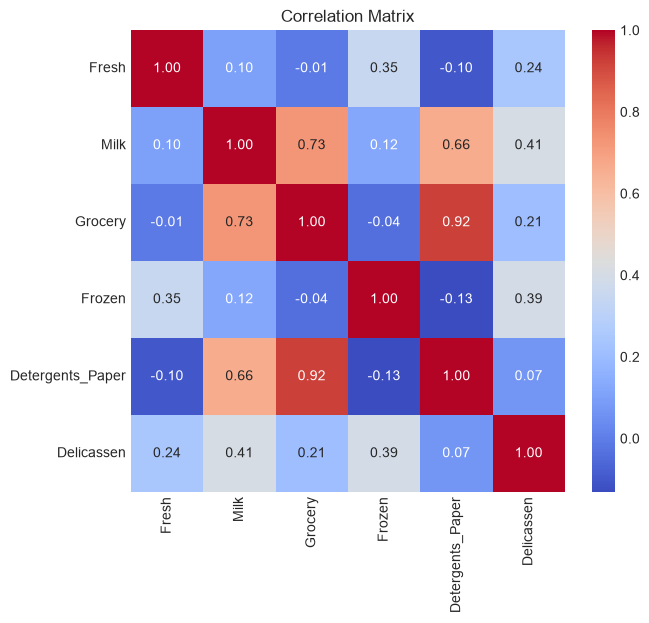

In [33]:
cols = [
    "Fresh", "Milk", "Grocery",
    "Frozen", "Detergents_Paper", "Delicassen"
]

corr = df[cols].corr()

plt.figure(figsize=(7,6))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix")
plt.show()

 - `Grocery` và `Detergents_Paper` có tương quan mạnh (0.92) cho thấy khách hàng có xu hướng chi tiêu cho hàng tạp hóa thì cũng chi tiêu cho sản phẩm tẩy rửa và giấy
 - `Milk` cũng có tương quan mạnh với `Grocery` (0.73) và `Detergents_Paper` (0.66), hình thành một nhóm các sản phẩm thường được mua cùng nhau. 

 - Dữ liệu phân lệch phải, outliers trải dài
 - Có sự chênh lệch giữa thang đo và độ biến thiên giữa các đặc trưng

Đề xuất:
 - Dùng StandardScaler + log1p hoặc RobustScaler để preprocessing
 - Đề xuất mô hình K_mean, bên cạnh đó có thể chọn Hierarchical Clustering (Ward linkage)


# TODO C — Chọn representation và preprocessing

Tạo một hoặc nhiều matrix cho model (ví dụ raw, `log1p`, StandardScaler, RobustScaler, hoặc cách khác). Bạn tự quyết định cách so sánh, nhưng cần:

- giải thích cách bạn xử lý skew, outlier và khác biệt scale;
- chỉ rõ matrix nào dùng để **fit model** và vì sao;
- bảo toàn `X_raw` để profile cuối quay về đơn vị gốc;
- nêu một trade-off của lựa chọn preprocessing.

> Có thể dùng `np.log1p(X_raw)` nếu phù hợp với dữ liệu không âm. Đây là gợi ý công cụ, không phải yêu cầu.

In [34]:
# Candidates

X_log = np.log1p(X_raw)
X_std = StandardScaler().fit_transform(X_raw)
X_log_std = StandardScaler().fit_transform(X_log)
X_robust = RobustScaler().fit_transform(X_raw)
X_log_robust = RobustScaler().fit_transform(X_log)

X_model = X_log_robust


- Dữ liệu có xu hướng lệch phải nặng -> Dùng log1p để cân bằng <br>
  Có oulier, khác biệt scale -> Dùng RobustScaler <br>
- Chọn log1p và RobustScaler để fit model
- Tradeoff: log1p và RobustScaler giúp giảm sự ảnh hưởng của sự lệch phải và outlier, đưa các đặc trưng về cùng thang đo. Tuy nhiên, việc biến đổi như thế không còn ở đơn vị gốc, gây ảnh hưởng đến việc diễn giải sau này và độ biến thiên của dữ liệu có thể bị nén lại, đặc biệt đối với các giá trị lớn

# TODO D — Khám phá model

So sánh ít nhất **hai thuật toán**. Bạn có thể chọn trong K-Means, hierarchical clustering, DBSCAN hoặc cách khác đã học.

Với từng candidate đáng cân nhắc, ghi lại:

- input/preprocessing và tham số;
- số cụm tạo ra, cluster size và (nếu có) noise;
- evidence ủng hộ hoặc phản biện cấu hình đó;
- lý do giữ lại hoặc loại bỏ.

Bạn không phải thử mọi thuật toán hay mọi tham số. Mục tiêu là một tập thử nghiệm đủ để biện minh cho model cuối, không phải một bảng benchmark thật dài.

In [35]:
# Analysis workspace — fit các model bạn muốn so sánh tại đây.
kmean = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)
hierachical = AgglomerativeClustering(
    n_clusters=4,
    linkage="ward"
)
dbscan = DBSCAN(
    eps=0.5,
    min_samples=5
)
# Hãy lưu labels của các candidate để tái sử dụng ở phần evaluation/profile.
kmean_label = kmean.fit_predict(X_model)
hierachical_label = hierachical.fit_predict(X_model)
dbscan_label = dbscan.fit_predict(X_model)

models = {
    "K-Means": (kmean, kmean_label),
    "Hierarchical": (hierachical, hierachical_label),
    "DBSCAN": (dbscan, dbscan_label),
}

summary = []

for name, (model, labels) in models.items():
    unique, counts = np.unique(labels, return_counts=True)

    cluster_sizes = {
        int(k): int(v)
        for k, v in zip(unique, counts)
    }

    noise = int(np.sum(labels == -1))

    summary.append({
        "Model": name,
        "Preprocessing": "log1p + RobustScaler",
        "Parameters": model.get_params(),
        "Clusters": len(cluster_sizes),
        "Cluster sizes": cluster_sizes,
        "Noise": noise
    })

summary_df = pd.DataFrame(summary)
display(summary_df)





,Model,Preprocessing,Parameters,Clusters,Cluster sizes,Noise
0,K-Means,log1p + RobustScaler,"{'algorithm': 'lloyd', 'copy_x': True, 'init':...",4,"{0: 122, 1: 158, 2: 96, 3: 64}",0
1,Hierarchical,log1p + RobustScaler,"{'compute_distances': False, 'compute_full_tre...",4,"{0: 126, 1: 175, 2: 49, 3: 90}",0
2,DBSCAN,log1p + RobustScaler,"{'algorithm': 'auto', 'eps': 0.5, 'leaf_size':...",8,"{-1: 375, 0: 22, 1: 13, 2: 9, 3: 5, 4: 6, 5: 7...",375


DBSCAN có quá nhiều noise -> loại

# TODO E — Evaluation, parameter choice và stability

Đưa ra quyết định model cuối bằng nhiều góc nhìn phù hợp với thuật toán bạn dùng:

- **Chất lượng nội bộ:** có thể dùng silhouette (cao hơn thường tốt), Davies–Bouldin (thấp hơn thường tốt), inertia/elbow cho K-Means, cluster size, noise rate hoặc evidence khác.
- **Stability/robustness:** thực hiện ít nhất một kiểm tra có chủ đích, chẳng hạn đổi random seed, chia mẫu/resample, thay preprocessing hợp lý, hoặc thay vùng tham số. Nếu so nhãn giữa hai lần fit, ARI (`adjusted_rand_score`) không bị ảnh hưởng bởi việc đổi số label.
- **Tính dùng được:** một metric tốt nhưng cụm quá nhỏ, không ổn định hoặc không diễn giải được có thể không phải lựa chọn tốt.

Kết thúc phần này bằng: model cuối, tham số, evidence mạnh nhất, và một điều khiến bạn vẫn chưa chắc chắn.

In [36]:
evaluation = []

for name, (_, labels) in models.items():

    # Bỏ qua nếu chỉ có 1 cụm hoặc toàn noise
    valid_labels = labels[labels != -1]

    if len(np.unique(valid_labels)) < 2:
        continue

    mask = labels != -1

    evaluation.append({
        "Model": name,
        "Silhouette": silhouette_score(X_model[mask], labels[mask]),
        "Davies-Bouldin": davies_bouldin_score(X_model[mask], labels[mask]),
        "Calinski-Harabasz": calinski_harabasz_score(X_model[mask], labels[mask]),
    })

evaluation_df = pd.DataFrame(evaluation)
display(evaluation_df)

,Model,Silhouette,Davies-Bouldin,Calinski-Harabasz
0,K-Means,0.20,1.41,120.84
1,Hierarchical,0.16,1.59,100.12
2,DBSCAN,0.33,0.91,56.86


In [37]:
kmeans_1 = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

kmeans_2 = KMeans(
    n_clusters=4,
    random_state=123,
    n_init=10
)

labels1 = kmeans_1.fit_predict(X_model)
labels2 = kmeans_2.fit_predict(X_model)

ari = adjusted_rand_score(labels1, labels2)

print("ARI =", ari)

ARI = 0.9080699438110301


# TODO F — Visualize để giao tiếp, không để chứng minh quá mức

Tạo visual phù hợp cho model cuối. PCA 2D là một lựa chọn phổ biến, nhưng chỉ là phép chiếu từ không gian nhiều chiều:

- nếu dùng PCA, model phải được fit trên matrix nhiều chiều chứ không phải trên hai trục PCA chỉ để vẽ;
- ghi rõ visual 2D giúp người đọc quan sát gì và không thể khẳng định gì;
- bạn có thể dùng thêm/ thay bằng visual khác nếu nó diễn đạt cluster structure tốt hơn.


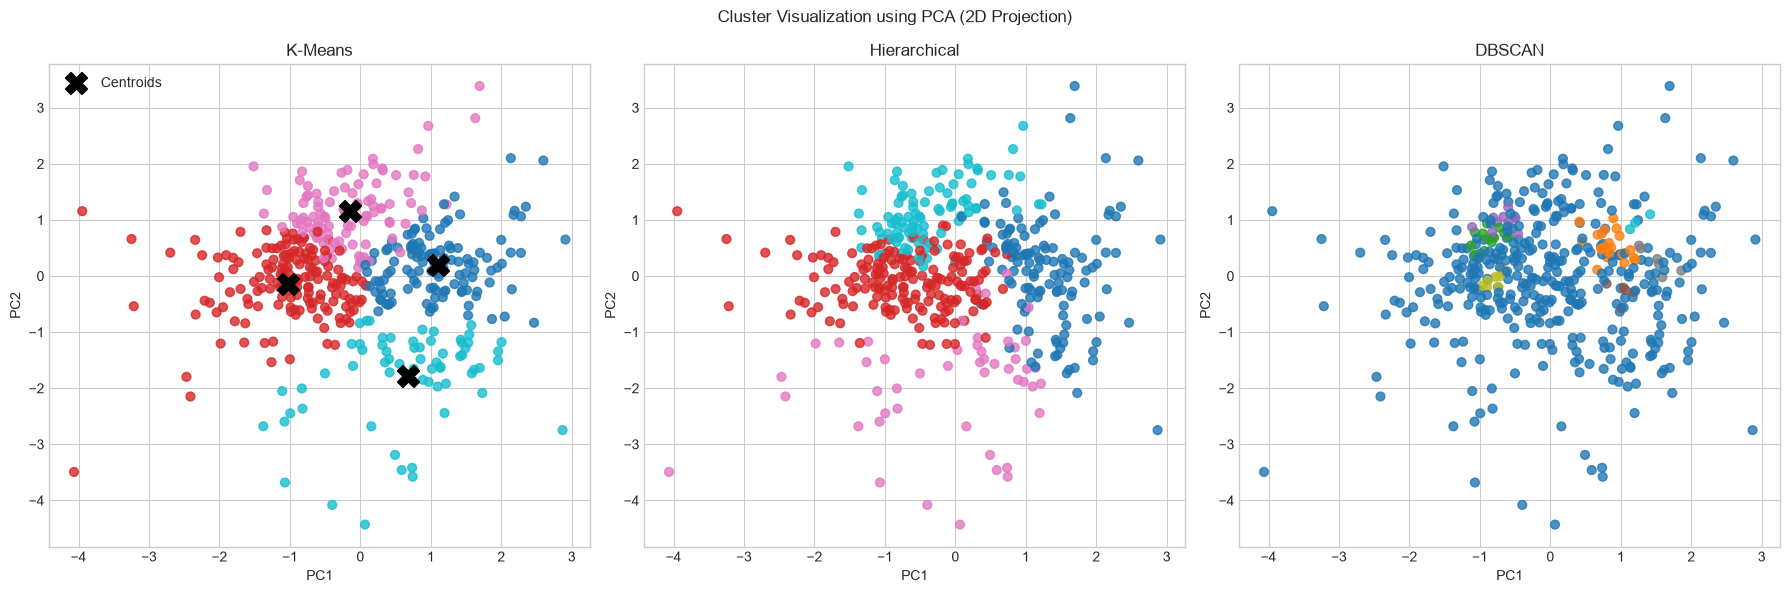

In [38]:
# Analysis workspace — visual cho model cuối.
# Có thể dùng PCA, nhưng không cần giới hạn ở PCA:
# coords = PCA(n_components=2, random_state=RANDOM_STATE).fit_transform(X_model)

pca = PCA(
    n_components=2,
    random_state=42
)

coords = pca.fit_transform(X_model)

# Chiếu tâm cụm xuống cùng không gian PCA
centers = pca.transform(kmean.cluster_centers_)

ppca = PCA(n_components=2, random_state=42)
coords = pca.fit_transform(X_model)

# Centroid của K-Means
centers = pca.transform(kmean.cluster_centers_)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

models = [
    ("K-Means", kmean_label),
    ("Hierarchical", hierachical_label),
    ("DBSCAN", dbscan_label)
]

for ax, (title, labels) in zip(axes, models):

    scatter = ax.scatter(
        coords[:, 0],
        coords[:, 1],
        c=labels,
        cmap="tab10",
        s=40,
        alpha=0.8
    )

    # Chỉ K-Means mới có centroid
    if title == "K-Means":
        ax.scatter(
            centers[:, 0],
            centers[:, 1],
            marker="X",
            s=250,
            c="black",
            label="Centroids"
        )
        ax.legend()

    ax.set_title(title)
    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2")

plt.suptitle("Cluster Visualization using PCA (2D Projection)")
plt.tight_layout()
plt.show()

# TODO G — Profile, đặt tên và action hypothesis

Quay về `X_raw`. Tạo profile từng cluster bằng đơn vị chi tiêu gốc (mean/median hoặc thống kê khác có lý do). Sau đó:

- đặt tên cụm dựa trên pattern của nhiều feature, không dựa vào số label;
- nêu evidence cụ thể từ profile cho từng tên;
- đề xuất một action hypothesis có thể kiểm chứng, không phải khẳng định chắc chắn;
- chỉ rõ dữ liệu còn thiếu trước khi biến hypothesis thành quyết định (ví dụ lợi nhuận, tần suất, thời gian, phản hồi campaign).

Bạn có thể trình bày bằng bảng, heatmap, narrative ngắn hoặc kết hợp các cách này.

,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
Cluster,,,,,,
0,"10,553.55","11,099.08","15,286.35","1,666.62","6,498.81","2,074.80"
1,"10,801.59","1,814.25","2,336.66","2,178.82",449.00,616.69
2,"22,466.77","4,964.18","5,054.93","7,844.76",770.91,"2,916.02"
3,"2,017.75","6,766.52","12,174.41",796.44,"5,157.08",631.91


,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
Cluster,,,,,,
0,"7,832.50","8,007.00","11,722.00","1,208.50","4,498.50","1,632.00"
1,"8,973.00","1,368.50","2,025.00","1,438.50",256.00,510.50
2,"18,869.00","3,381.00","4,290.50","5,920.00",532.50,"1,870.00"
3,894.50,"6,358.50","10,502.50",344.50,"4,373.50",302.00


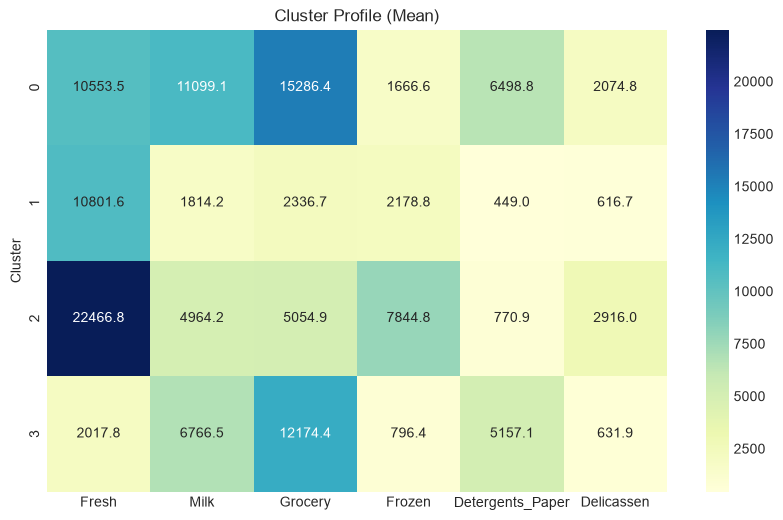

In [39]:
df_profile = X_raw.copy()

df_profile["Cluster"] = kmean_label

cluster_mean = df_profile.groupby("Cluster").mean()

cluster_median = df_profile.groupby("Cluster").median()

display(cluster_mean)
display(cluster_median)

plt.figure(figsize=(10,6))

sns.heatmap(
    cluster_mean,
    annot=True,
    fmt=".1f",
    cmap="YlGnBu"
)

plt.title("Cluster Profile (Mean)")
plt.show()

Đặt tên
- Cluster 0: nhóm tập trung vào hàng tạp hóa và nhu yếu phẩm.
- Cluster 1: nhóm mua ít và chủ yếu tập trung vào thực phẩm tươi.
- Cluster 2: nhóm mua thực phẩm tươi và đông lạnh với số lượng lớn.
- Cluster 1: nhóm này chủ yếu mua hàng tiêu dùng thiết yếu hơn là thực phẩm tươi.

# TODO H — Executive summary

Viết 150–250 từ cho người ra quyết định:

1. Có nên dùng segmentation này ngay, thử nghiệm giới hạn, hay chưa nên dùng? Vì sao?
2. Quyết định model/preprocessing cuối và evidence ngắn gọn.
3. Hai insight profile quan trọng nhất.
4. Action thử trước và cách đánh giá nó.
5. Giới hạn quan trọng nhất của phân tích.

1. Nên dùng cân bằng giới hạn, chưa nên nhân rộng ra. Tại vì KMeans có thể tìm ra các cụm và đặc trưng của nó nhưng vẫn chưa kết luận được nó là đúng và phù hợp với thực tiễn
2. 
- Model: K-Means (n_clusters = 4, random_state = 42, n_init = 10)
- Preprocessing: log1p + RobustScaler
- Evidence:
Dữ liệu ban đầu lệch phải, có outlier và khác biệt về thang đo nên log1p + RobustScaler giúp giảm ảnh hưởng của các vấn đề này.
K-Means tạo hai cụm với kích thước hợp lý không có noise.
DBSCAN loại bỏ phần lớn dữ liệu thành noise nên không phù hợp với tập dữ liệu. K-Means đạt các chỉ số đánh giá nội bộ tốt hơn hoặc tương đương Hierarchical.
3. 
- Cluster 0: nhóm tập trung vào hàng tạp hóa và nhu yếu phẩm.
- Cluster 1: nhóm mua ít và chủ yếu tập trung vào thực phẩm tươi.
4. Thử triển khai 1 chiến dịch marketing, ví dụ như tăng ưu đãi cho nhóm mua nhiều, giảm ưu đãi cho nhóm mua ít, so sánh kết quả, ...
5.Phân cụm chỉ dựa trên các đặc điểm hiện có, không có sự tham gia của các yếu tố ảnh hưởng khác như thời gian, thiên tai, chính trị thế giới,... nên chưa thể kết luận kết quả nó đưa ra là chính xác 100%
## Checklist trước khi nộp

- [đã xong] Notebook chạy từ đầu đến cuối, không phụ thuộc hidden state.
- [đã xong] EDA dẫn tới một lựa chọn phân tích, không chỉ mô tả dữ liệu.
- [đã xong] Có ≥2 thuật toán và quyết định model có evidence.
- [đã xong] Có kiểm tra stability/robustness và diễn giải kết quả.
- [đã xong] Không đọc PCA 2D như bằng chứng duy nhất.
- [đã xong] Profile/diễn giải dùng đơn vị gốc, tên cụm và action có evidence.
- [đã xong] Có giới hạn và kết luận business rõ ràng.
